# SVM Variant — Class-Specific Margins

In the previous lab, we saw that the hyperplane learnt by an SVM classifier lies exactly halfway between the two sets of support vectors. This is because both classes were held to the same margin constraint — every point had to satisfy $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1$, regardless of class.

But this symmetry is not fundamental to SVMs — it is just a consequence of using the same constant on the right-hand side for all points. We can generalize this by replacing that constant with a **per-class margin target** $c_i$:

$$y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq c_i, \quad c_i = \begin{cases} c_{\text{pos}} & \text{if } y_i = +1 \\ c_{\text{neg}} & \text{if } y_i = -1 \end{cases}$$

The two margin boundaries are now at $\mathbf{w}^\top \mathbf{x} + b = +c_{\text{pos}}$ and $\mathbf{w}^\top \mathbf{x} + b = -c_{\text{neg}}$, so the decision boundary is no longer equidistant from both classes — it shifts toward the class with the smaller margin target.

## What changes in the dual

The dual objective picks up the change directly. The $\mathbf{q}$ vector, which was uniformly $-\mathbf{1}$, becomes the per-sample vector $-\mathbf{c}$:

$$\max_{\boldsymbol{\alpha}} \sum_i c_i \alpha_i - \frac{1}{2} \sum_i \sum_j \alpha_i \alpha_j y_i y_j\, \mathbf{x}_i^\top \mathbf{x}_j \quad \text{s.t.} \quad \sum_i \alpha_i y_i = 0,\quad \alpha_i \geq 0$$

Everything else — $P$, $A$, $b$, $G$, $h$ — stays exactly the same as before. So in code, only the `q` vector changes.

## What changes in bias recovery

The KKT condition for a support vector is now $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = c_i$, so:

$$b = c_i \cdot y_i - \mathbf{w}^\top \mathbf{x}_i$$

where $c_i$ is the margin target of that support vector specifically — not a fixed $1$ anymore.

## Imports

In [33]:
import numpy as np
import cvxopt
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cvxopt.solvers.options["show_progress"] = False

## `SVM` Class

In [ ]:
class SVM:
    def __init__(self):
        self.w = 0
        self.bias = 0
        self.sv_X = []
        self.c_pos = 1.0
        self.c_neg = 1.0

    def fit(self, X, y, c_pos=1.0, c_neg=1.0):
        # default c_pos=c_neg=1.0 reduces to standard hard-margin SVM
        n_samples, _ = X.shape
        self.c_pos = c_pos
        self.c_neg = c_neg

        # per-sample margin target: c_pos for positive class, c_neg for negative
        c = np.where(y == 1, c_pos, c_neg)
        K = (y[:, None] * X) @ (y[:, None] * X).T

        P = cvxopt.matrix(K.astype(float))
        q = cvxopt.matrix(-c.astype(float).reshape(-1, 1))  # (n,1) column vector, consistent with Lab 7
        A = cvxopt.matrix(y.reshape(1, -1).astype(float))
        b = cvxopt.matrix(np.zeros(1))
        G = cvxopt.matrix(-np.eye(n_samples))
        h = cvxopt.matrix(np.zeros(n_samples))

        soln = cvxopt.solvers.qp(P, q, G, h, A, b)
        alphas = np.array(soln['x']).flatten()

        # Only support vectors have non-zero Lagrangian Parameters
        sv_idx = alphas > 1e-5
        sv_X = X[sv_idx]
        sv_y = y[sv_idx]
        sv_c = c[sv_idx]

        w = ((alphas * y)[:, None] * X).sum(axis=0)
        bias = sv_c[0] * sv_y[0] - np.dot(sv_X[0], w)  # from KKT: y_i(w·x_i + b) = c_i

        self.w = w
        self.bias = bias
        self.sv_X = sv_X

    def plot(self, X, y, title, subplot_info):
        background = ListedColormap(['cyan', 'lightgreen'])
        foreground = ListedColormap(['blue', 'green'])

        plt.subplot(*subplot_info)
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        plt.pcolormesh(xx, yy, Z, cmap=background, alpha=0.3, shading='auto')

        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=foreground)
        plt.scatter(self.sv_X[:, 0], self.sv_X[:, 1], s=100, facecolors='none', edgecolors='k', label='SVs')

        x_plot = np.linspace(x_min, x_max, 100)
        y_plot       = (-self.w[0] * x_plot - self.bias) / self.w[1]                # decision boundary: w·x + b = 0
        y_margin_pos = (self.c_pos - self.w[0] * x_plot - self.bias) / self.w[1]    # positive margin: w·x + b = +c_pos
        y_margin_neg = (-self.c_neg - self.w[0] * x_plot - self.bias) / self.w[1]   # negative margin: w·x + b = -c_neg

        plt.plot(x_plot, y_plot, 'k-', linewidth=2, label='Decision Boundary')
        plt.plot(x_plot, y_margin_pos, 'r--', linewidth=2, label='Margins')
        plt.plot(x_plot, y_margin_neg, 'r--', linewidth=2)
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.ylim(y_min, y_max)

    def predict(self, X):
        return np.sign(X @ self.w + self.bias)

## Visualization

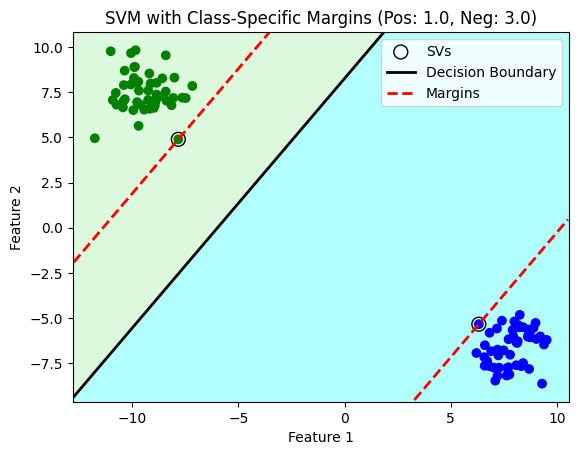

In [39]:
X, y = make_blobs(n_samples=100, centers=2, n_features=2)
y[y == 0] = -1

hard_margin_svm = SVM()
hard_margin_svm.fit(X, y, c_pos=1.0, c_neg=3.0)
plot_title = f"SVM with Class-Specific Margins (Pos: {hard_margin_svm.c_pos}, Neg: {hard_margin_svm.c_neg})"
hard_margin_svm.plot(X, y, plot_title, (1, 1, 1))
plt.show()